# Klasifikasi Sampah — Transfer Learning EfficientNetB0
**Model:** EfficientNetB0 (pretrained ImageNet) | **Dataset:** 10 Jenis, 4000 Gambar | **Metode:** Feature Extraction

| No | Bagian | No | Bagian |
|---|---|---|---|
| 1 | Import & Konfigurasi | 6 | Visualisasi Riwayat Training |
| 2 | Fungsi Pembantu | 7 | Evaluasi Model |
| 3 | Preprocessing | 8 | Confusion Matrix |
| 4 | Arsitektur Model | 9 | Analisis Kesalahan Prediksi |
| 5 | Training Model | 10 | Penyimpanan Model & Ringkasan |

**Kategori dataset:**
- **Organik** : buah, bunga, daging, daun, makanan
- **Anorganik** : cardboard, glass, metal, paper, plastic

## 1. Import & Konfigurasi
Mengimpor semua library yang dibutuhkan dan menetapkan seluruh parameter global dalam satu kamus `KONFIGURASI`. Semua nilai yang perlu diubah cukup diubah di sini tanpa menelusuri seluruh kode.

In [1]:
import os, shutil, random, warnings, json, zipfile, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import classification_report, confusion_matrix

# Menetapkan seed di semua library agar hasil eksperimen bisa direproduksi
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
warnings.filterwarnings('ignore')

# Satu kamus terpusat untuk semua parameter — ubah di sini, berlaku ke seluruh notebook
KONFIGURASI = {
    'PATH_ZIP'      : '/content/Garbage_clasiffication.zip',   # lokasi file ZIP dataset
    'DIR_EKSTRAK'   : '/content/Garbage',                       # folder hasil ekstrak ZIP
    'DIR_DATAR'     : '/content/Garbage_Flat',                  # folder setelah struktur diratakan
    'DIR_SPLIT'     : '/content/Garbage_Split',                 # folder train / val / test
    'DIR_OUTPUT'    : '/content/hasil_output',                  # folder penyimpanan semua hasil
    'UKURAN_GAMBAR' : (224, 224),    # resolusi input wajib EfficientNetB0
    'UKURAN_BATCH'  : 16,            # jumlah gambar per iterasi training
    'RASIO_TRAIN'   : 0.70,          # 70% data untuk melatih model
    'RASIO_VAL'     : 0.15,          # 15% untuk memantau training (validasi)
    'JUMLAH_EPOCH'  : 20,            # batas maksimum epoch (bisa berhenti lebih awal via EarlyStopping)
}

# Buat folder output jika belum ada
Path(KONFIGURASI['DIR_OUTPUT']).mkdir(exist_ok=True)
print('Konfigurasi selesai.')


Konfigurasi selesai.


## 2. Fungsi Pembantu
- `cetak_judul` — mencetak judul bagian dengan garis pembatas.
- `simpan_grafik` — menyimpan grafik ke folder output sekaligus menampilkannya.

In [2]:
def cetak_judul(judul, lebar=80):
    """Mencetak judul bagian dengan garis pembatas agar output mudah dibaca."""
    print(f"\n{'='*lebar}\n{judul.center(lebar)}\n{'='*lebar}")

def simpan_grafik(nama_file, dpi=150):
    """Merapikan layout, menyimpan grafik ke DIR_OUTPUT, lalu menampilkannya di notebook."""
    plt.tight_layout()  # otomatis rapikan jarak antar elemen plot
    plt.savefig(f"{KONFIGURASI['DIR_OUTPUT']}/{nama_file}", dpi=dpi, bbox_inches='tight')
    plt.show()
    print(f"  [Tersimpan] {nama_file}")

print('Fungsi pembantu siap.')


Fungsi pembantu siap.


## 3. Preprocessing
Mempersiapkan data dari file ZIP hingga siap dibaca model melalui empat tahap:

**3A** Ekstraksi ZIP → **3B** Perataan folder → **3C** Pembagian train/val/test → **3D** Pembacaan data & Augmentasi

> **Terminologi yang digunakan secara konsisten di seluruh notebook:**
> - **Jenis** = sub-kelas spesifik (buah, glass, plastic, dst.)
> - **Kategori** = kelompok besar (Organik / Anorganik)

### 3A — Ekstraksi Dataset
Membuka file ZIP dan mengekstrak isinya ke folder lokal.

In [3]:
# Buka file ZIP dataset dan ekstrak semua isinya ke folder lokal
with zipfile.ZipFile(KONFIGURASI['PATH_ZIP'], 'r') as f:
    f.extractall(KONFIGURASI['DIR_EKSTRAK'])
print(f"  Dataset diekstrak ke : {KONFIGURASI['DIR_EKSTRAK']}")


  Dataset diekstrak ke : /content/Garbage


### 3B — Perataan Struktur Folder
Dataset asli berlapis dua: **Kategori/ → Jenis/** (contoh: `Organic/buah/`).
Diratakan menjadi satu lapisan **Jenis/** agar `ImageDataGenerator` membaca label otomatis dari nama folder.

In [4]:
direktori_sumber = Path(KONFIGURASI['DIR_EKSTRAK'])
direktori_datar  = Path(KONFIGURASI['DIR_DATAR'])

# Hapus folder lama jika ada, lalu buat ulang agar hasilnya bersih
if direktori_datar.exists(): shutil.rmtree(direktori_datar)
direktori_datar.mkdir(parents=True)

statistik = []
# Iterasi dua lapisan folder: Kategori (Organik/Anorganik) → Jenis (buah, glass, dst.)
for kategori in direktori_sumber.iterdir():
    if not kategori.is_dir(): continue
    for jenis in kategori.iterdir():
        if not jenis.is_dir(): continue
        direktori_jenis = direktori_datar / jenis.name
        direktori_jenis.mkdir(exist_ok=True)
        # Ambil hanya file gambar yang valid berdasarkan ekstensinya
        daftar_gambar = [f for f in jenis.glob('*')
                         if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')]
        # Salin tiap gambar ke folder datar (tanpa sub-folder kategori)
        for g in daftar_gambar:
            shutil.copy2(g, direktori_jenis / g.name)
        # Simpan ringkasan jumlah gambar per jenis untuk ditampilkan
        statistik.append({'jenis': jenis.name, 'kategori': kategori.name,
                          'jumlah': len(daftar_gambar)})

# Buat DataFrame statistik lalu tampilkan ringkasannya
df_statistik = pd.DataFrame(statistik).sort_values('jenis').reset_index(drop=True)
for _, baris in df_statistik.iterrows():
    print(f"  [{baris['kategori']:10s}] {baris['jenis']:15s} : {baris['jumlah']:4d} gambar")
print(f"\n  Total : {df_statistik['jumlah'].sum()} gambar | {len(df_statistik)} jenis")


  [organik   ] buah            :  400 gambar
  [organik   ] bunga           :  400 gambar
  [anorganik ] cardboard       :  400 gambar
  [organik   ] daging          :  400 gambar
  [organik   ] daun            :  400 gambar
  [anorganik ] glass           :  400 gambar
  [organik   ] makanan         :  400 gambar
  [anorganik ] metal           :  400 gambar
  [anorganik ] paper           :  400 gambar
  [anorganik ] plastic         :  400 gambar

  Total : 4000 gambar | 10 jenis


### 3C — Pembagian Dataset: 70% Train / 15% Val / 15% Test
Setiap jenis dibagi secara terpisah agar proporsi merata. Pembagian dilakukan secara **fisik** — masing-masing subset memiliki foldernya sendiri:

```
Garbage_Split/
  ├── train/  ← 70% gambar per jenis  → digunakan model untuk belajar (bobot diperbarui)
  ├── val/    ← 15% gambar per jenis  → dipantau callback, model tidak belajar dari sini
  └── test/   ← 15% gambar per jenis  → evaluasi akhir, tidak disentuh selama training
```

In [5]:
direktori_split = Path(KONFIGURASI['DIR_SPLIT'])
# Hapus folder split lama jika ada, buat ulang struktur train/val/test
if direktori_split.exists(): shutil.rmtree(direktori_split)
for bagian in ('train', 'val', 'test'):
    (direktori_split / bagian).mkdir(parents=True)

for baris in df_statistik.itertuples():
    daftar_gambar = sorted((direktori_datar / baris.jenis).glob('*'))
    random.shuffle(daftar_gambar)  # acak urutan agar pembagian tidak bias
    # Hitung jumlah gambar untuk train dan val berdasarkan rasio
    n_train = int(len(daftar_gambar) * KONFIGURASI['RASIO_TRAIN'])
    n_val   = int(len(daftar_gambar) * KONFIGURASI['RASIO_VAL'])
    # Potong daftar gambar menjadi tiga kelompok: train, val, dan sisanya untuk test
    pembagian = {
        'train': daftar_gambar[:n_train],
        'val'  : daftar_gambar[n_train : n_train + n_val],
        'test' : daftar_gambar[n_train + n_val:]  # sisa otomatis jadi test
    }
    # Salin setiap gambar ke sub-folder subset yang sesuai
    for bagian, berkas in pembagian.items():
        tujuan = direktori_split / bagian / baris.jenis
        tujuan.mkdir(exist_ok=True)
        for f in berkas: shutil.copy2(f, tujuan / f.name)

# Cetak tabel ringkasan jumlah gambar per subset per jenis
print(f"  {'Jenis':15s} | {'Train':>5} | {'Val':>5} | {'Test':>5}")
print(f"  {'-'*42}")
total_tr = total_vl = total_ts = 0
for baris in df_statistik.itertuples():
    n_tr = int(baris.jumlah * KONFIGURASI['RASIO_TRAIN'])
    n_vl = int(baris.jumlah * KONFIGURASI['RASIO_VAL'])
    n_ts = baris.jumlah - n_tr - n_vl
    total_tr += n_tr; total_vl += n_vl; total_ts += n_ts
    print(f"  {baris.jenis:15s} | {n_tr:5d} | {n_vl:5d} | {n_ts:5d}")
print(f"  {'-'*42}")
print(f"  {'TOTAL':15s} | {total_tr:5d} | {total_vl:5d} | {total_ts:5d}")
print(f"\n  Rasio  : Train 70% | Val 15% | Test 15%")
print(f"  Lokasi : {KONFIGURASI['DIR_SPLIT']}/train | .../val | .../test")


  Jenis           | Train |   Val |  Test
  ------------------------------------------
  buah            |   280 |    60 |    60
  bunga           |   280 |    60 |    60
  cardboard       |   280 |    60 |    60
  daging          |   280 |    60 |    60
  daun            |   280 |    60 |    60
  glass           |   280 |    60 |    60
  makanan         |   280 |    60 |    60
  metal           |   280 |    60 |    60
  paper           |   280 |    60 |    60
  plastic         |   280 |    60 |    60
  ------------------------------------------
  TOTAL           |  2800 |   600 |   600

  Rasio  : Train 70% | Val 15% | Test 15%
  Lokasi : /content/Garbage_Split/train | .../val | .../test


### 3D — Pembacaan Data & Augmentasi Training

**`ImageDataGenerator` adalah alat pembaca data (data loader)**, bukan augmentasi. Ia bertugas mengalirkan gambar dari folder ke model secara efisien per batch. Dua hal yang selalu dilakukan pada **semua** subset (train, val, test):

1. **Membaca & resize gambar** dari folder ke ukuran 224×224 piksel.
2. **Memanggil `preprocess_input`** — mengubah nilai piksel dari [0–255] menjadi [-1, 1] agar sesuai bobot pretrained EfficientNetB0.

**Augmentasi adalah konfigurasi terpisah** yang hanya ditambahkan ke pembaca data training. Data val dan test menggunakan pembaca yang sama **tanpa parameter augmentasi apapun** — gambar dibaca apa adanya agar Val dan test mengukur performa model pada kondisi nyata. Jika gambar evaluasi diubah, hasil pengukuran tidak merepresentasikan kondisi sesungguhnya dan tidak valid sebagai tolok ukur.

**Dua jenis augmentasi yang diterapkan pada data training:**
- **Augmentasi Spasial** — `rotation_range`, `width/height_shift_range`, `shear_range`, `zoom_range`, `horizontal_flip`: mensimulasikan variasi posisi dan sudut kamera.
- **Augmentasi Fotometri** — `brightness_range`: mensimulasikan variasi kondisi pencahayaan.

In [6]:
# ── PEMBACAAN DATA TRAINING — augmentasi spasial + fotometri diaktifkan
# preprocess_input: mengubah piksel [0–255] → [-1, 1] sesuai format bobot pretrained EfficientNetB0
generator_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,            # spasial: rotasi acak ±25°
    width_shift_range=0.15,       # spasial: geser horizontal maks. 15%
    height_shift_range=0.15,      # spasial: geser vertikal maks. 15%
    shear_range=0.15,             # spasial: distorsi miring maks. 15%
    zoom_range=0.15,              # spasial: zoom in/out maks. 15%
    horizontal_flip=True,         # spasial: cermin horizontal acak
    brightness_range=[0.8, 1.2],  # fotometri: kecerahan ±20%
    fill_mode='nearest'           # isi piksel kosong akibat transformasi dengan nilai terdekat
).flow_from_directory(
    f"{KONFIGURASI['DIR_SPLIT']}/train",
    target_size=KONFIGURASI['UKURAN_GAMBAR'],  # resize semua gambar ke 224×224
    batch_size=KONFIGURASI['UKURAN_BATCH'],
    class_mode='categorical', shuffle=True, seed=42  # one-hot label, data diacak tiap epoch
)

# ── PEMBACAAN DATA VALIDASI — tanpa augmentasi, gambar dibaca apa adanya
generator_val = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    f"{KONFIGURASI['DIR_SPLIT']}/val",
    target_size=KONFIGURASI['UKURAN_GAMBAR'],
    batch_size=KONFIGURASI['UKURAN_BATCH'],
    class_mode='categorical', shuffle=False  # urutan tetap agar evaluasi konsisten
)

# ── PEMBACAAN DATA TEST — tanpa augmentasi, tidak disentuh selama training
generator_test = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    f"{KONFIGURASI['DIR_SPLIT']}/test",
    target_size=KONFIGURASI['UKURAN_GAMBAR'],
    batch_size=KONFIGURASI['UKURAN_BATCH'],
    class_mode='categorical', shuffle=False
)

# Ambil nama kelas dari indeks generator train
nama_kelas = list(generator_train.class_indices.keys())
total      = generator_train.samples + generator_val.samples + generator_test.samples
print(f"\n  10 jenis yang dikenali model : {nama_kelas}")
print(f"  {'─'*56}")
print(f"  Training  : {generator_train.samples:4d} gambar  — dibaca dengan augmentasi spasial + fotometri")
print(f"  Validasi  : {generator_val.samples:4d}  gambar  — dibaca tanpa augmentasi")
print(f"  Test      : {generator_test.samples:4d}  gambar  — dibaca tanpa augmentasi")
print(f"  {'─'*56}")
print(f"  Total     : {total} gambar dari {len(nama_kelas)} jenis")


Found 2800 images belonging to 10 classes.
Found 600 images belonging to 10 classes.
Found 600 images belonging to 10 classes.

  10 jenis yang dikenali model : ['buah', 'bunga', 'cardboard', 'daging', 'daun', 'glass', 'makanan', 'metal', 'paper', 'plastic']
  ────────────────────────────────────────────────────────
  Training  : 2800 gambar  — dibaca dengan augmentasi spasial + fotometri
  Validasi  :  600  gambar  — dibaca tanpa augmentasi
  Test      :  600  gambar  — dibaca tanpa augmentasi
  ────────────────────────────────────────────────────────
  Total     : 4000 gambar dari 10 jenis


#### Contoh Gambar Asli per Jenis
Menampilkan 4 sampel dari setiap jenis untuk memverifikasi semua jenis terbaca dengan benar. Gambar ditampilkan apa adanya sebelum preprocessing.

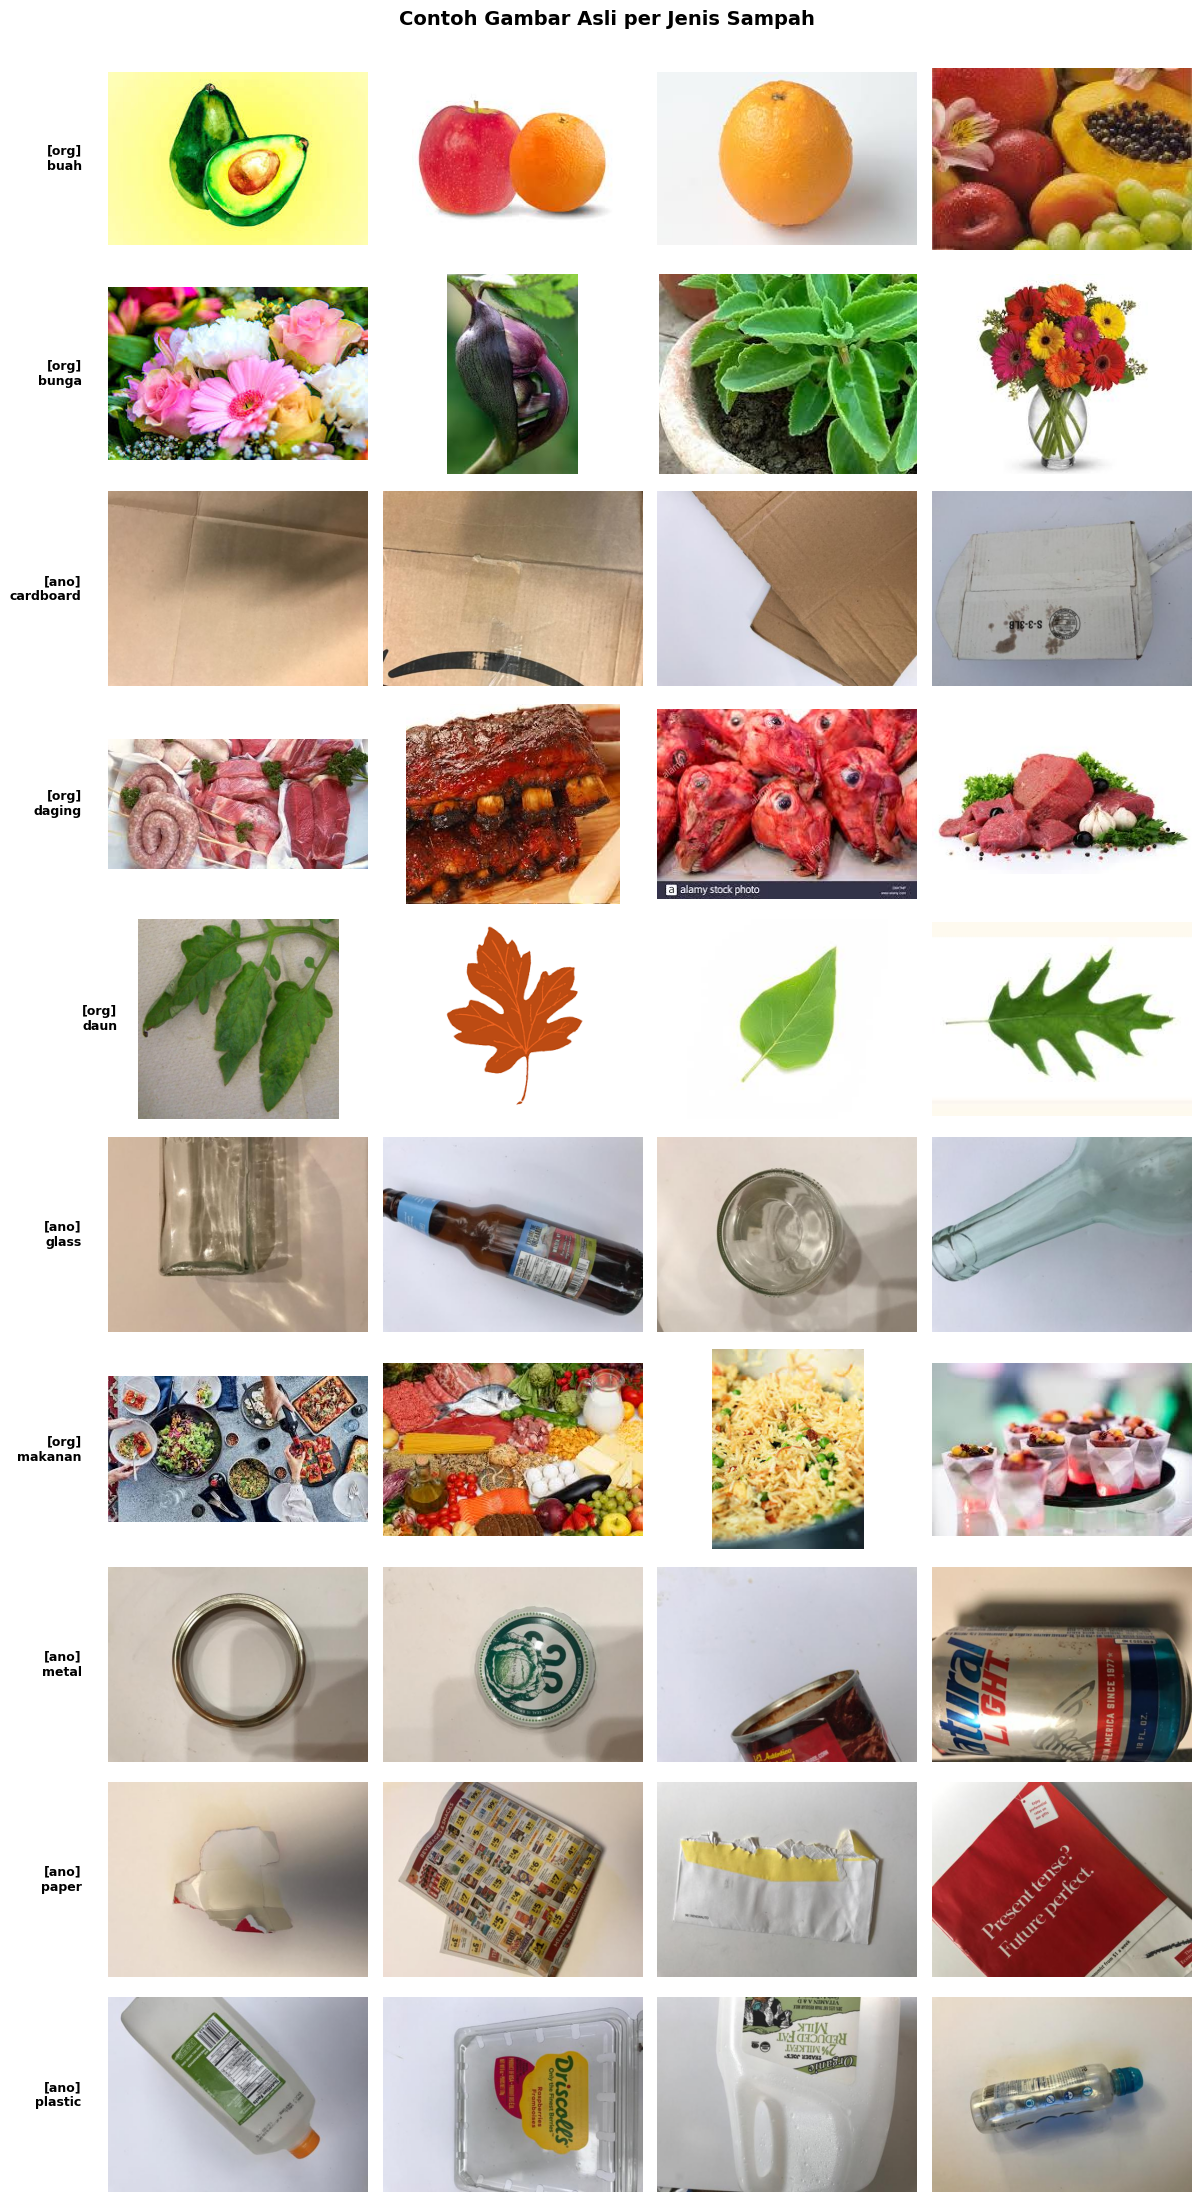

  [Tersimpan] 02_contoh_gambar_asli.png


In [7]:
# Buat grid gambar: baris = jenis sampah, kolom = 4 sampel acak dari jenis tersebut
fig, axes = plt.subplots(len(df_statistik), 4, figsize=(12, len(df_statistik) * 2.2))
for i, baris in df_statistik.iterrows():
    # Kumpulkan semua file gambar (.jpg dan .png) untuk jenis ini
    gambar_jenis = (list((direktori_datar / baris['jenis']).glob('*.jpg')) +
                    list((direktori_datar / baris['jenis']).glob('*.png')))
    # Pilih 4 gambar acak, lalu tampilkan di setiap kolom
    for j, path in enumerate(random.sample(gambar_jenis, min(4, len(gambar_jenis)))):
        ax = axes[i, j]
        ax.imshow(Image.open(path)); ax.axis('off')
        if j == 0:  # tambahkan label jenis hanya di kolom pertama
            ax.text(-0.1, 0.5, f"[{baris['kategori'][:3]}]\n{baris['jenis']}",
                    transform=ax.transAxes, fontsize=9, weight='bold',
                    ha='right', va='center')
plt.suptitle("Contoh Gambar Asli per Jenis Sampah", fontsize=14, weight='bold', y=1.0)
simpan_grafik("02_contoh_gambar_asli.png")


#### Visualisasi Augmentasi per Jenis
Setiap baris menampilkan **satu jenis sampah** dengan empat variasi augmentasi yang dihasilkan dari **gambar yang sama**. Perhatikan perbedaan rotasi, geser, zoom, flip, dan kecerahan di setiap kolom — inilah variasi yang dilihat model selama training.

Ditampilkan 2 jenis Organik (buah, daun) dan 2 jenis Anorganik (glass, plastic).

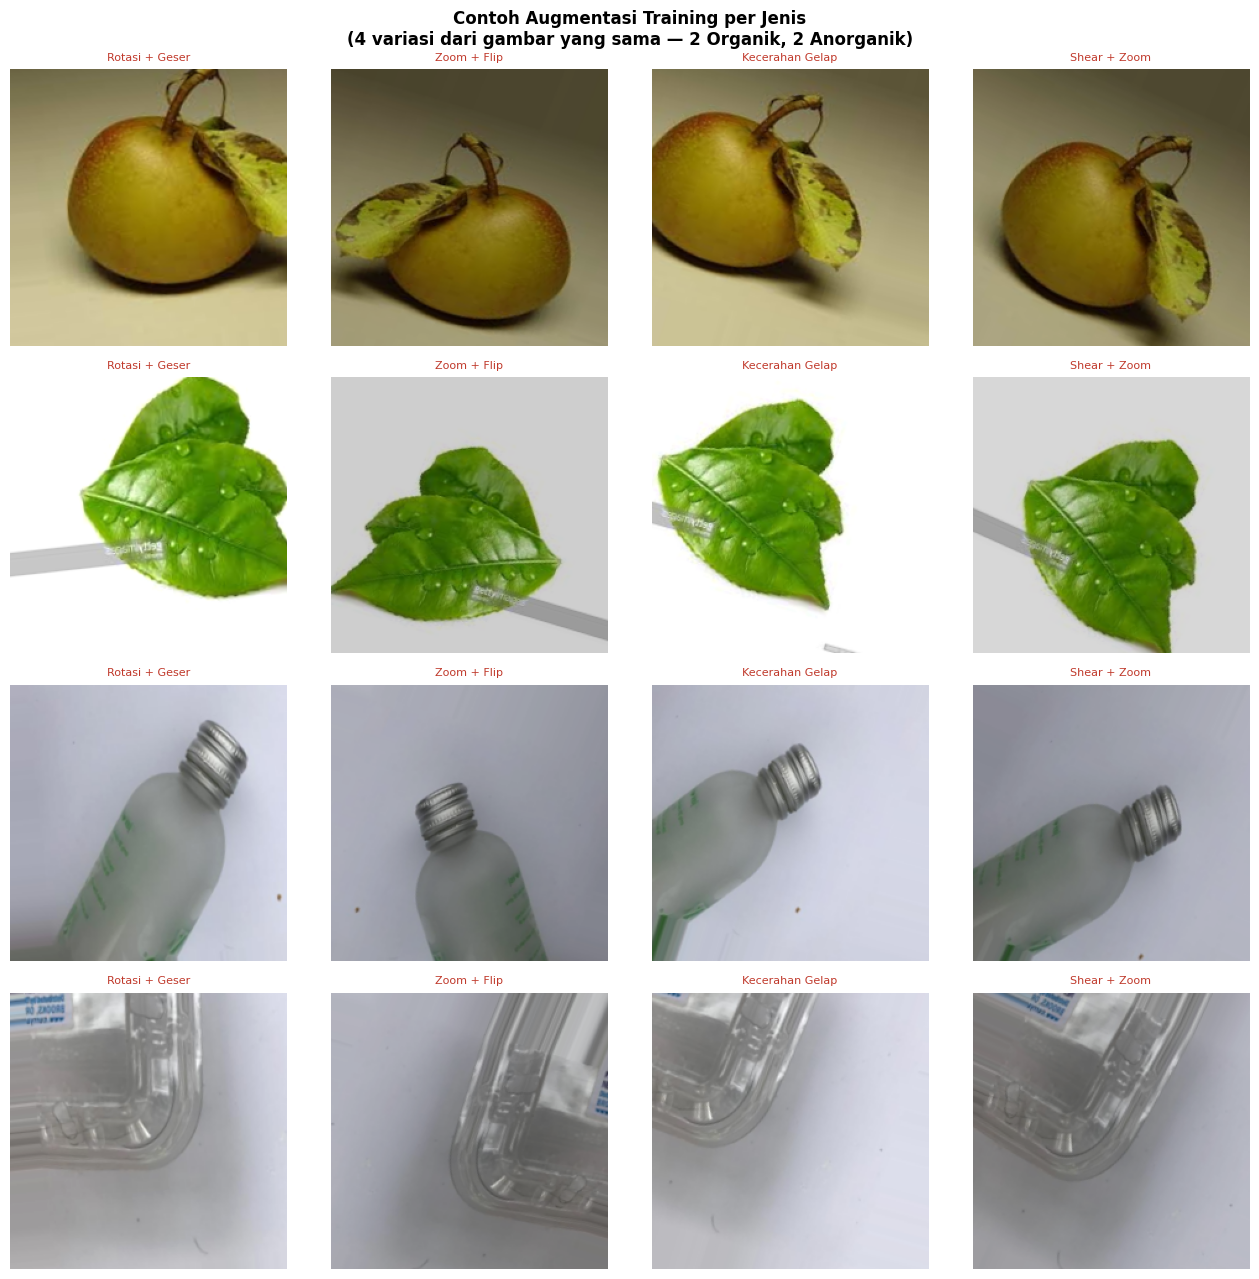

  [Tersimpan] 03_visualisasi_augmentasi.png


In [8]:
# Generator khusus visualisasi — rescale ke [0,1] agar bisa ditampilkan matplotlib
gen_vis = ImageDataGenerator(
    rotation_range=25, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest', rescale=1./255
)

# Pilih 2 jenis Organik dan 2 Anorganik sebagai contoh representatif
contoh_jenis = [('buah','Organik'), ('daun','Organik'),
                ('glass','Anorganik'), ('plastic','Anorganik')]
label_kolom  = ['Rotasi + Geser', 'Zoom + Flip', 'Kecerahan Gelap', 'Shear + Zoom']

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for baris_idx, (nama_jenis, nama_kategori) in enumerate(contoh_jenis):
    # Ambil satu gambar dari jenis yang dipilih sebagai gambar sumber
    gambar_path = list((direktori_datar / nama_jenis).glob('*.jpg'))[0]
    # Tambah dimensi batch agar bisa diproses oleh generator (shape: 1×H×W×3)
    gambar_arr  = np.expand_dims(np.array(Image.open(gambar_path).resize((224, 224))), 0)
    gen_iter    = gen_vis.flow(gambar_arr, batch_size=1, seed=42)
    for kolom_idx in range(4):
        ax = axes[baris_idx, kolom_idx]
        # next() menghasilkan satu batch augmentasi baru setiap kali dipanggil
        ax.imshow(np.clip(next(gen_iter)[0], 0, 1)); ax.axis('off')
        ax.set_title(label_kolom[kolom_idx], fontsize=8, color='#c0392b')
        if kolom_idx == 0:  # label jenis hanya di kolom pertama
            ax.set_ylabel(f"[{nama_kategori}]\n{nama_jenis}",
                          fontsize=9, weight='bold', rotation=0,
                          labelpad=70, va='center')

plt.suptitle(
    "Contoh Augmentasi Training per Jenis\n"
    "(4 variasi dari gambar yang sama — 2 Organik, 2 Anorganik)",
    fontsize=12, weight='bold'
)
generator_train.reset()  # kembalikan posisi generator train ke awal setelah visualisasi
simpan_grafik("03_visualisasi_augmentasi.png")


## 4. Arsitektur Model
EfficientNetB0 digunakan sebagai **feature extractor** dengan pendekatan *transfer learning*. Base model dibekukan (`trainable=False`) — bobotnya tidak berubah saat training. Hanya *custom classification head* yang dilatih.

**Alur data melalui model:**
```
Input (224×224×3)
    ↓  EfficientNetB0 — frozen (4.049.571 parameter tidak dilatih)
    ↓  Output: feature map (7×7×1.280)
    ↓  GlobalAveragePooling2D  →  vektor 1.280 dimensi
    ↓  Dense(256, ReLU) + L2   →  pelajari kombinasi fitur, L2 cegah bobot berlebih
    ↓  BatchNormalization       →  stabilkan distribusi nilai antar batch
    ↓  Dropout(0.5)             →  nonaktifkan 50% neuron acak, cegah overfitting
    ↓  Dense(10, Softmax)       →  10 probabilitas jenis sampah (jumlah = 1)
```

In [9]:
# Muat EfficientNetB0 pretrained ImageNet; exclude top layer (FC asli dihapus)
model_dasar = EfficientNetB0(weights='imagenet', include_top=False,
                              input_shape=(*KONFIGURASI['UKURAN_GAMBAR'], 3))
model_dasar.trainable = False  # bekukan semua bobot base model — tidak ikut diupdate saat training

# Susun arsitektur model dengan Functional API
inputs = layers.Input(shape=(*KONFIGURASI['UKURAN_GAMBAR'], 3))  # lapisan input gambar
x      = model_dasar(inputs, training=False)    # lewatkan ke base model; training=False matikan BatchNorm base
x      = layers.GlobalAveragePooling2D()(x)     # ubah feature map 7×7×1280 menjadi vektor 1280-dimensi
x      = layers.Dense(256, activation='relu',
                       kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)  # pelajari fitur, L2 cegah bobot terlalu besar
x      = layers.BatchNormalization()(x)         # stabilkan distribusi nilai antar batch
x      = layers.Dropout(0.5)(x)                 # nonaktifkan 50% neuron acak — cegah overfitting
output = layers.Dense(len(nama_kelas), activation='softmax')(x)  # output: probabilitas 10 kelas (jumlah = 1)

# Bangun model dari input ke output
model = models.Model(inputs, output)
model.summary()

# Hitung dan tampilkan jumlah parameter yang dilatih vs yang dibekukan
param_latih = sum(tf.size(v).numpy() for v in model.trainable_variables)
param_beku  = sum(tf.size(v).numpy() for v in model.non_trainable_variables)
print(f"\n  Parameter dilatih (custom head)  : {param_latih:,}")
print(f"  Parameter beku    (EfficientNetB0): {param_beku:,}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,101 (16.71 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)


  Parameter dilatih (custom head)  : 331,018
  Parameter beku    (EfficientNetB0): 4,050,103


## 5. Training Model
**Optimizer:** Adam (lr = 2e-3) | **Loss:** Categorical Crossentropy | **Metrik:** Akurasi & Top-3 Akurasi

Tiga callback otomatis aktif selama training:
- **EarlyStopping** (patience=5) — hentikan jika `val_accuracy` tidak naik 5 epoch berturut-turut; bobot terbaik dikembalikan otomatis.
- **ReduceLROnPlateau** (patience=3, ×0.3) — kurangi *learning rate* jika `val_loss` stagnan 3 epoch.
- **ModelCheckpoint** — simpan model otomatis setiap kali `val_accuracy` membaik.

In [10]:
# Kompilasi model: tentukan optimizer, fungsi loss, dan metrik evaluasi
model.compile(
    optimizer=optimizers.Adam(learning_rate=2e-3),        # Adam dengan lr awal 0.002
    loss='categorical_crossentropy',                       # loss standar untuk klasifikasi multi-kelas one-hot
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]  # akurasi & top-3
)

daftar_callback = [
    # Hentikan training jika val_accuracy tidak membaik dalam 5 epoch; kembalikan bobot terbaik
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                             restore_best_weights=True, verbose=1),
    # Kurangi learning rate ×0.3 jika val_loss stagnan 3 epoch berturut-turut
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                 patience=3, min_lr=1e-7, verbose=1),
    # Simpan otomatis model terbaik (berdasarkan val_accuracy) ke disk
    callbacks.ModelCheckpoint(filepath=f"{KONFIGURASI['DIR_OUTPUT']}/model_terbaik.keras",
                               monitor='val_accuracy', save_best_only=True, verbose=0)
]

# Mulai proses training
riwayat_training = model.fit(
    generator_train,
    validation_data=generator_val,
    epochs=KONFIGURASI['JUMLAH_EPOCH'],
    callbacks=daftar_callback,
    verbose=1
)
print(f"\n  Val Accuracy terbaik : {max(riwayat_training.history['val_accuracy'])*100:.2f}%")


Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.7311 - loss: 1.1045 - top3_acc: 0.9414 - val_accuracy: 0.8883 - val_loss: 0.5865 - val_top3_acc: 0.9933 - learning_rate: 0.0020
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.8471 - loss: 0.7329 - top3_acc: 0.9839 - val_accuracy: 0.8950 - val_loss: 0.6008 - val_top3_acc: 0.9950 - learning_rate: 0.0020
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.8671 - loss: 0.6607 - top3_acc: 0.9875 - val_accuracy: 0.9000 - val_loss: 0.6055 - val_top3_acc: 0.9933 - learning_rate: 0.0020
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8648 - loss: 0.6464 - top3_acc: 0.9920
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0006000000284984708.
175/175 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.8743 - loss: 0.6385 - top3_acc: 0.9925 - val_accuracy: 0.8883 - val_loss: 0.6506 - val_top3_acc: 0.9950 - learning_rate: 0.0020
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/ste

## 6. Visualisasi Riwayat Training
Kurva akurasi dan loss training vs validasi per epoch. Kedua kurva yang berdekatan dan sama-sama meningkat menandakan model belajar dengan baik tanpa overfitting.

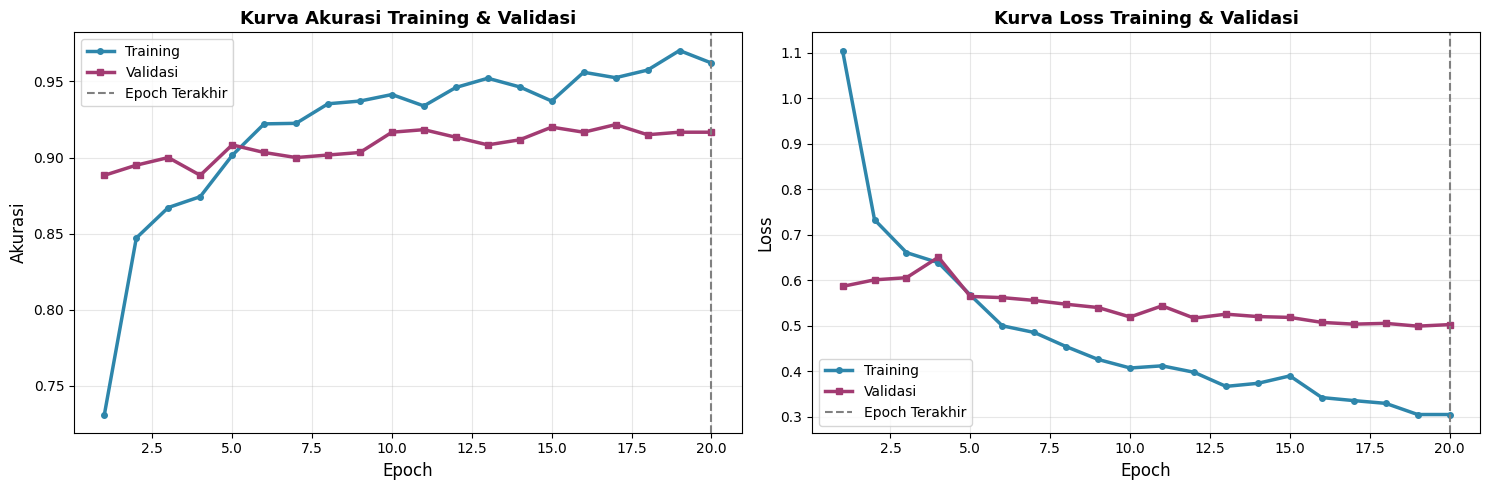

  [Tersimpan] 04_riwayat_training.png


In [11]:
# Ambil riwayat metrik dari objek hasil training
akurasi      = riwayat_training.history['accuracy']
akurasi_val  = riwayat_training.history['val_accuracy']
kerugian     = riwayat_training.history['loss']
kerugian_val = riwayat_training.history['val_loss']
daftar_epoch = range(1, len(akurasi) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Plot kurva akurasi dan loss dalam satu loop untuk menghindari duplikasi kode
for ax, d_train, d_val, label, judul in [
    (ax1, akurasi,  akurasi_val,  'Akurasi', 'Kurva Akurasi Training & Validasi'),
    (ax2, kerugian, kerugian_val, 'Loss',    'Kurva Loss Training & Validasi')
]:
    ax.plot(daftar_epoch, d_train, 'o-', color='#2E86AB', lw=2.5, label='Training', ms=4)
    ax.plot(daftar_epoch, d_val,   's-', color='#A23B72', lw=2.5, label='Validasi',  ms=4)
    ax.axvline(len(daftar_epoch), color='gray', ls='--', lw=1.5, label='Epoch Terakhir')  # penanda epoch berhenti
    ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel(label, fontsize=12)
    ax.set_title(judul, fontsize=13, weight='bold')
    ax.legend(); ax.grid(alpha=0.3)
simpan_grafik("04_riwayat_training.png")


## 7. Evaluasi Model
Mengukur performa model pada data validasi dan data test.

> Data validasi digunakan callback (EarlyStopping & ReduceLROnPlateau) selama training, sehingga model secara tidak langsung menyesuaikan diri terhadap val. Angka **test** lebih jujur mencerminkan performa sesungguhnya karena data test benar-benar tidak pernah disentuh selama training.

Metrik yang dilaporkan: **Akurasi**, **Top-3 Akurasi**, **Precision/Recall/F1 per jenis**, dan **TP/TN/FP/FN per jenis**.

In [12]:
hasil = {}
# Jalankan evaluasi untuk validasi dan test dalam satu loop
for nama_set, gen in [('val', generator_val), ('test', generator_test)]:
    gen.reset()  # kembalikan generator ke awal agar urutan prediksi cocok dengan label asli
    prob       = model.predict(gen, verbose=0)    # dapatkan probabilitas prediksi tiap kelas
    prediksi   = np.argmax(prob, axis=1)           # ambil indeks kelas dengan probabilitas tertinggi
    label_asli = gen.classes                       # label ground truth dari generator
    hasil[nama_set] = {
        'label_asli'  : label_asli,
        'prediksi'    : prediksi,
        'probabilitas': prob,
        'akurasi'     : np.mean(prediksi == label_asli) * 100,
        # Top-3: prediksi dianggap benar jika label asli masuk 3 kelas teratas
        'top3'        : sum(1 for i, t in enumerate(label_asli)
                            if t in np.argsort(prob[i])[-3:]) / len(label_asli) * 100
    }

print(f"\n  {'Metrik':<30} {'Validasi':>12} {'Test':>12}")
print(f"  {'─'*56}")
print(f"  {'Akurasi':<30} {hasil['val']['akurasi']:>11.2f}% {hasil['test']['akurasi']:>11.2f}%")
print(f"  {'Top-3 Akurasi':<30} {hasil['val']['top3']:>11.2f}% {hasil['test']['top3']:>11.2f}%")
print(f"  {'Akurasi Training Terbaik':<30} {max(akurasi)*100:>11.2f}%")
print(f"  {'Akurasi Validasi Terbaik':<30} {max(akurasi_val)*100:>11.2f}%")

# Tampilkan laporan lengkap precision/recall/F1 per kelas pada data test
print(f"\n  Laporan Klasifikasi — Data Test\n  {'─'*60}")
print(classification_report(hasil['test']['label_asli'], hasil['test']['prediksi'],
                             target_names=nama_kelas, digits=4))
# Simpan laporan ke CSV untuk keperluan dokumentasi
pd.DataFrame(
    classification_report(hasil['test']['label_asli'], hasil['test']['prediksi'],
                          target_names=nama_kelas, output_dict=True)
).transpose().to_csv(f"{KONFIGURASI['DIR_OUTPUT']}/laporan_klasifikasi.csv")

print(f"  Detail Prediksi per Jenis — Data Test\n  {'─'*65}")
akurasi_per_jenis = []
total = len(hasil['test']['label_asli'])
for i, kelas in enumerate(nama_kelas):
    # Hitung TP, FP, FN, TN secara manual untuk setiap kelas
    TP = int(np.sum((hasil['test']['prediksi']==i) & (hasil['test']['label_asli']==i)))  # benar diprediksi kelas ini
    FP = int(np.sum((hasil['test']['prediksi']==i) & (hasil['test']['label_asli']!=i)))  # salah dikira kelas ini
    FN = int(np.sum((hasil['test']['prediksi']!=i) & (hasil['test']['label_asli']==i)))  # kelas ini tidak terdeteksi
    TN = total - TP - FP - FN                                                             # semua sisa yang benar bukan kelas ini
    akurasi_kelas = (TP + TN) / total * 100
    akurasi_per_jenis.append({'jenis':kelas,'akurasi':akurasi_kelas,'TP':TP,'FP':FP,'FN':FN,'TN':TN})
    print(f"  {kelas:15s} : {akurasi_kelas:6.2f}%  (TP={TP:3d}, TN={TN:3d}, FP={FP:3d}, FN={FN:3d})")
pd.DataFrame(akurasi_per_jenis).to_csv(
    f"{KONFIGURASI['DIR_OUTPUT']}/detail_per_jenis.csv", index=False)



  Metrik                             Validasi         Test
  ────────────────────────────────────────────────────────
  Akurasi                              92.17%       90.67%
  Top-3 Akurasi                        99.50%       99.50%
  Akurasi Training Terbaik             97.04%
  Akurasi Validasi Terbaik             92.17%

  Laporan Klasifikasi — Data Test
  ────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        buah     0.8507    0.9500    0.8976        60
       bunga     0.9273    0.8500    0.8870        60
   cardboard     0.9833    0.9833    0.9833        60
      daging     0.9286    0.8667    0.8966        60
        daun     0.9138    0.8833    0.8983        60
       glass     0.8772    0.8333    0.8547        60
     makanan     0.8387    0.8667    0.8525        60
       metal     0.8676    0.9833    0.9219        60
       paper     0.9667    0.9667    0.9667        60
     plastic     0.9298    0.883

## 8. Confusion Matrix
Tabel 10×10 yang merangkum semua hasil prediksi secara visual.
- **Diagonal utama (hijau)** = prediksi benar: jenis asli = jenis yang diprediksi.
- **Di luar diagonal (merah)** = prediksi salah; angka menunjukkan seberapa sering jenis di baris diprediksi sebagai jenis di kolom.

Sumbu Y = jenis sebenarnya | Sumbu X = jenis yang diprediksi model.

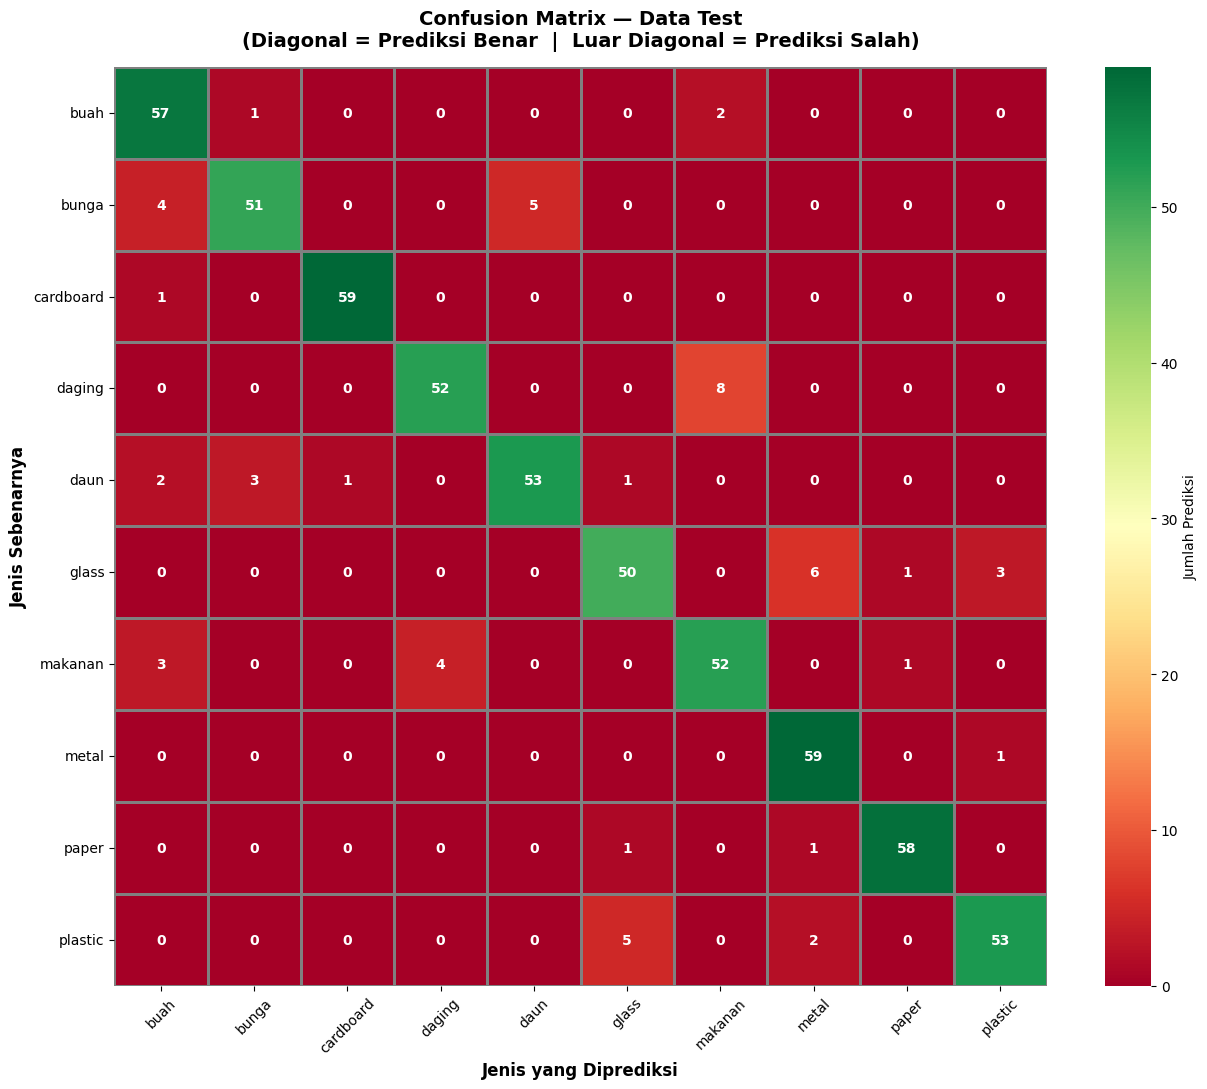

  [Tersimpan] 05_confusion_matrix.png


In [13]:
# Hitung confusion matrix dari prediksi vs label asli pada data test
matriks_konfusi = confusion_matrix(hasil['test']['label_asli'], hasil['test']['prediksi'])

fig, ax = plt.subplots(figsize=(13, 11))
# Tampilkan sebagai heatmap berwarna: hijau = banyak benar, merah = banyak salah
sns.heatmap(matriks_konfusi, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=nama_kelas, yticklabels=nama_kelas,
            cbar_kws={'label': 'Jumlah Prediksi'}, linewidths=1, linecolor='gray',
            annot_kws={'size': 10, 'weight': 'bold'}, ax=ax)
ax.set_title(
    "Confusion Matrix — Data Test\n"
    "(Diagonal = Prediksi Benar  |  Luar Diagonal = Prediksi Salah)",
    weight='bold', fontsize=14, pad=15
)
ax.set_ylabel("Jenis Sebenarnya", weight='bold', fontsize=12)    # sumbu Y = label asli
ax.set_xlabel("Jenis yang Diprediksi", weight='bold', fontsize=12)  # sumbu X = hasil prediksi model
ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)
simpan_grafik("05_confusion_matrix.png")
# Simpan confusion matrix ke CSV agar mudah dianalisis lebih lanjut
pd.DataFrame(matriks_konfusi, index=nama_kelas, columns=nama_kelas
).to_csv(f"{KONFIGURASI['DIR_OUTPUT']}/confusion_matrix.csv")


## 9. Analisis Kesalahan Prediksi
Contoh gambar yang salah diprediksi beserta skor kepercayaan (*confidence score*) model, diikuti ringkasan jenis mana yang paling sering tertukar.

  Total kesalahan : 56 dari 600 gambar


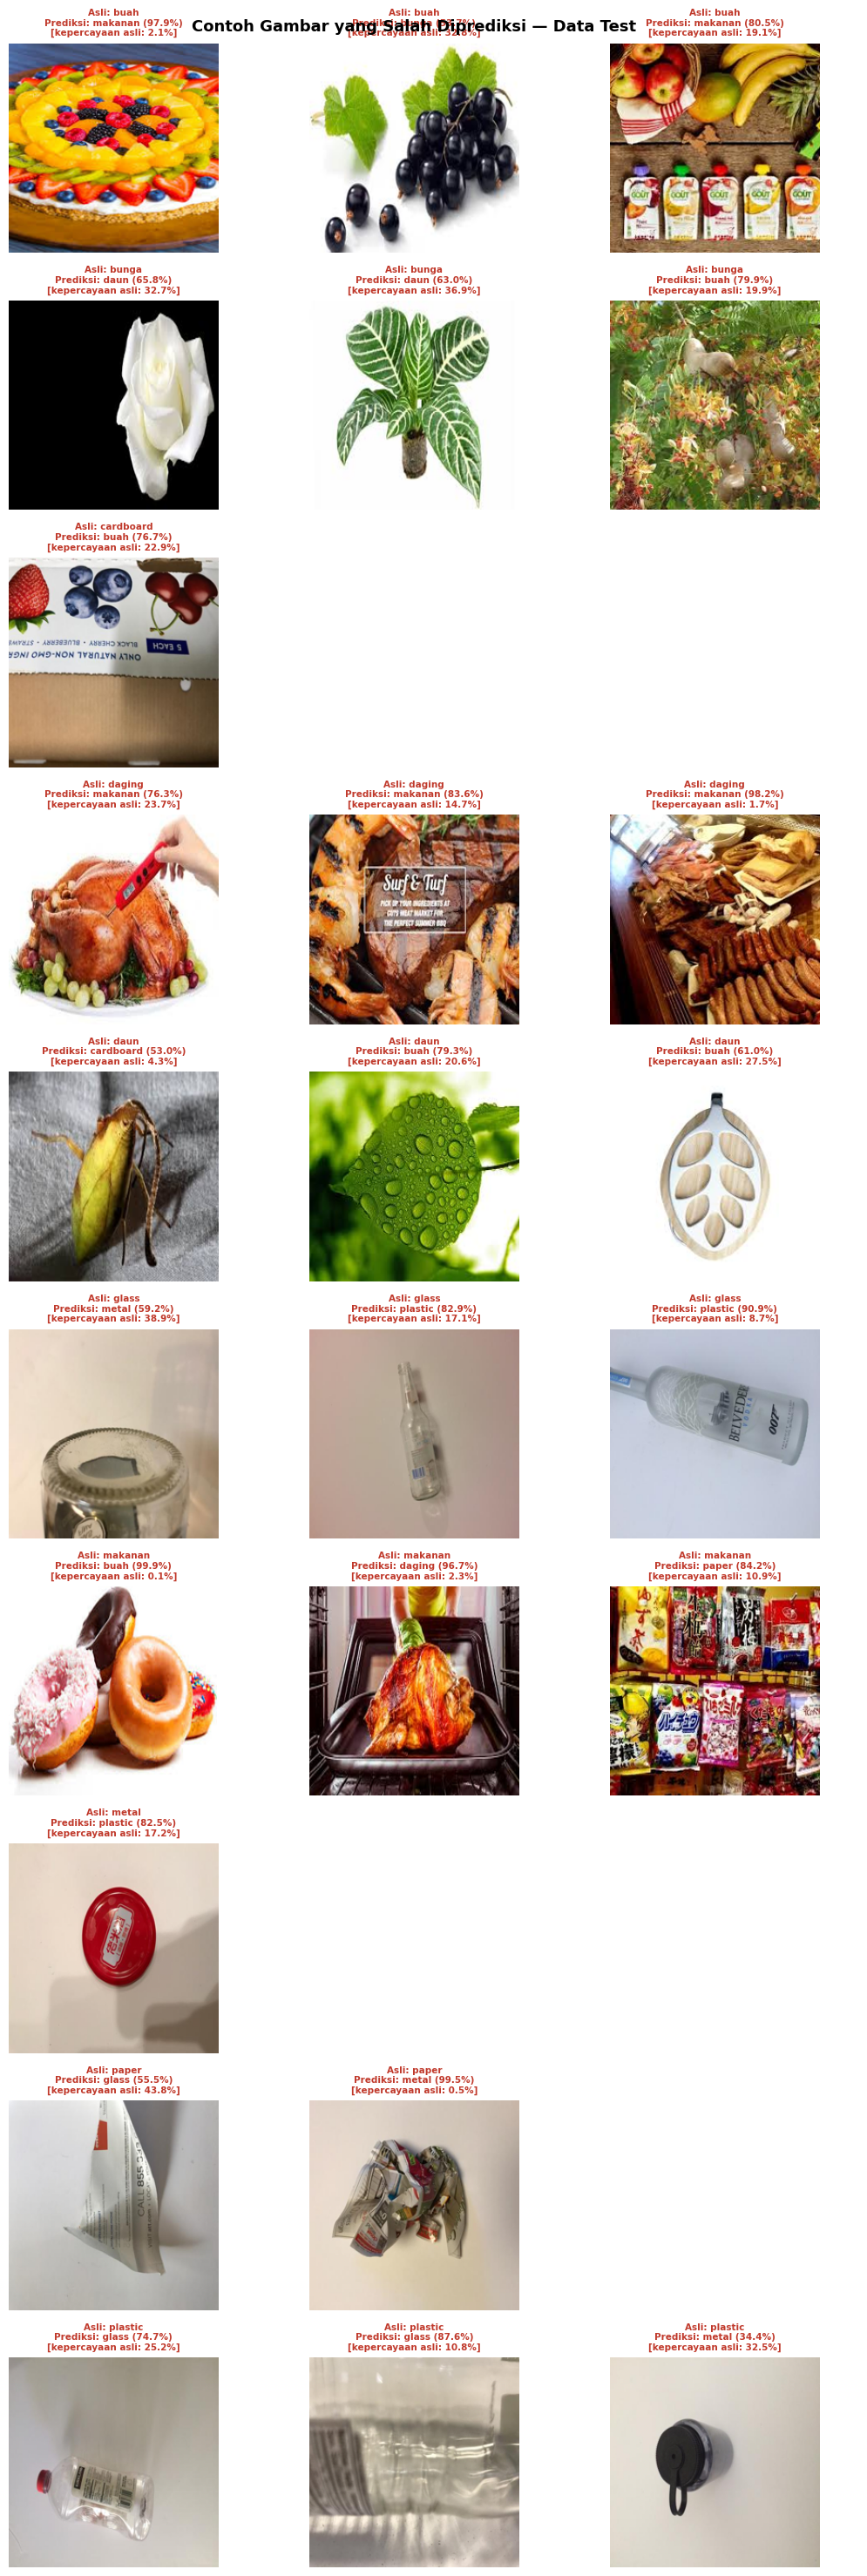

  [Tersimpan] 06_kesalahan_prediksi.png

  Jenis Asli      Paling Sering Diprediksi Sebagai  Frekuensi
  ───────────────────────────────────────────────────────────
  buah            makanan                                   2x
  bunga           daun                                      5x
  cardboard       buah                                      1x
  daging          makanan                                   8x
  daun            bunga                                     3x
  glass           metal                                     6x
  makanan         daging                                    4x
  metal           plastic                                   1x
  paper           metal                                     1x
  plastic         glass                                     5x


In [14]:
generator_test.reset()  # reset agar urutan filepath sesuai dengan urutan prediksi
file_test    = np.array(generator_test.filepaths)
# Cari semua indeks gambar yang prediksinya tidak cocok dengan label asli
indeks_salah = np.where(hasil['test']['prediksi'] != hasil['test']['label_asli'])[0]
print(f"  Total kesalahan : {len(indeks_salah)} dari {len(hasil['test']['label_asli'])} gambar")

# Buat grid visualisasi: baris = tiap kelas, kolom = maksimal 3 contoh gambar salah
fig, axes = plt.subplots(len(nama_kelas), 3, figsize=(10.5, len(nama_kelas) * 3))
for i, kelas in enumerate(nama_kelas):
    id_kelas        = generator_train.class_indices[kelas]
    # Filter hanya kesalahan yang label aslinya adalah kelas ini
    salah_per_kelas = indeks_salah[hasil['test']['label_asli'][indeks_salah] == id_kelas]
    for ax in axes[i]: ax.axis('off')  # sembunyikan sumbu untuk semua kolom dulu
    for j, idx in enumerate(salah_per_kelas[:3]):  # tampilkan maks. 3 contoh per kelas
        ax         = axes[i, j]
        label_pred = nama_kelas[hasil['test']['prediksi'][idx]]
        conf_pred  = hasil['test']['probabilitas'][idx][hasil['test']['prediksi'][idx]] * 100  # keyakinan prediksi salah
        conf_asli  = hasil['test']['probabilitas'][idx][id_kelas] * 100                        # keyakinan terhadap label benar
        ax.imshow(Image.open(file_test[idx]).resize((224, 224))); ax.axis('off')
        ax.set_title(
            f"Asli: {kelas}\nPrediksi: {label_pred} ({conf_pred:.1f}%)\n"
            f"[kepercayaan asli: {conf_asli:.1f}%]",
            fontsize=7.5, color='#c0392b', weight='bold'
        )
        if j == 0:  # label kelas hanya di kolom pertama
            axes[i, 0].set_ylabel(kelas, fontsize=9, weight='bold',
                                   rotation=0, labelpad=60, va='center')
plt.suptitle("Contoh Gambar yang Salah Diprediksi — Data Test", fontsize=13, weight='bold')
simpan_grafik("06_kesalahan_prediksi.png")

# Cetak ringkasan: untuk tiap kelas, tampilkan ke kelas mana paling sering salah diprediksi
print(f"\n  {'Jenis Asli':<15} {'Paling Sering Diprediksi Sebagai':<32} {'Frekuensi':>10}")
print(f"  {'─'*59}")
ringkasan_kesalahan = []
for kelas in nama_kelas:
    id_kelas        = generator_train.class_indices[kelas]
    salah_per_kelas = indeks_salah[hasil['test']['label_asli'][indeks_salah] == id_kelas]
    if len(salah_per_kelas) == 0: continue  # lewati kelas yang tidak punya kesalahan
    daftar_pred     = [nama_kelas[hasil['test']['prediksi'][i]] for i in salah_per_kelas]
    # Cari kelas tujuan yang paling sering jadi kesalahan prediksi
    salah_terbanyak = max(set(daftar_pred), key=daftar_pred.count)
    jumlah          = daftar_pred.count(salah_terbanyak)
    ringkasan_kesalahan.append({'jenis_asli':kelas,'salah_ke':salah_terbanyak,'jumlah':jumlah})
    print(f"  {kelas:<15} {salah_terbanyak:<32} {jumlah:>10}x")
pd.DataFrame(ringkasan_kesalahan).to_csv(
    f"{KONFIGURASI['DIR_OUTPUT']}/ringkasan_kesalahan.csv", index=False)


## 10. Penyimpanan Model & Ringkasan Akhir
Menyimpan model dalam dua format, metadata JSON, mengemas seluruh output ke ZIP, dan mencetak rekap akhir.

In [15]:
# ── Simpan model dalam dua format: .keras (format modern) dan .h5 (kompatibilitas lama)
model.save(f"{KONFIGURASI['DIR_OUTPUT']}/model_waste_classifier.keras")
model.save(f"{KONFIGURASI['DIR_OUTPUT']}/model_waste_classifier.h5")

# ── Metadata JSON: simpan semua info penting model agar mudah dilacak nanti
konfigurasi_model = {
    'nama_model'      : 'EfficientNetB0_Waste_Classifier',
    'jumlah_jenis'    : len(nama_kelas),
    'nama_jenis'      : nama_kelas,
    'ukuran_input'    : [224, 224, 3],
    'pembagian_data'  : {'train': KONFIGURASI['RASIO_TRAIN'],
                         'val'  : KONFIGURASI['RASIO_VAL'],
                         'test' : round(1 - KONFIGURASI['RASIO_TRAIN'] - KONFIGURASI['RASIO_VAL'], 2)},
    'metrik'          : {'akurasi_val' : float(hasil['val']['akurasi']),
                         'akurasi_test': float(hasil['test']['akurasi']),
                         'top3_val'    : float(hasil['val']['top3']),
                         'top3_test'   : float(hasil['test']['top3'])},
    'tanggal_training': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')  # catat waktu training
}
with open(f"{KONFIGURASI['DIR_OUTPUT']}/konfigurasi_model.json", 'w') as f:
    json.dump(konfigurasi_model, f, indent=2)

# ── Kemas hasil_output/ dan dataset_split/ ke dalam satu file ZIP untuk diunduh
path_zip = '/content/hasil_klasifikasi_sampah.zip'
with zipfile.ZipFile(path_zip, 'w', zipfile.ZIP_DEFLATED) as z:
    for folder, nama_dalam in [
        (KONFIGURASI['DIR_OUTPUT'], 'hasil_output'),   # model, grafik, laporan CSV
        (KONFIGURASI['DIR_SPLIT'],  'dataset_split'),  # data train/val/test yang sudah dibagi
    ]:
        for root, _, files in os.walk(folder):
            for file in files:
                src = os.path.join(root, file)
                # Simpan file ke ZIP dengan path relatif agar struktur folder terjaga
                z.write(src, os.path.join(nama_dalam, os.path.relpath(src, folder)))

# ── Cetak ringkasan akhir hasil keseluruhan proses
total_gambar = generator_train.samples + generator_val.samples + generator_test.samples
zip_mb       = os.path.getsize(path_zip) / (1024 * 1024)
sep = '─' * 52
print('=' * 52)
print('RINGKASAN HASIL MODEL EFFICIENTNETB0'.center(52))
print('=' * 52)
print(f'  Dataset           : {len(nama_kelas)} jenis | {total_gambar} gambar')
print(f'  Pembagian         : Train {generator_train.samples} | Val {generator_val.samples} | Test {generator_test.samples}')
print(f'  Epoch dijalankan  : {len(akurasi)} dari {KONFIGURASI["JUMLAH_EPOCH"]} epoch')
print(f'  Total parameter   : {model.count_params():,}')
print(sep)
print(f'  Akurasi Validasi   : {hasil["val"]["akurasi"]:.2f}%')
print(f'  Akurasi Test       : {hasil["test"]["akurasi"]:.2f}%')
print(f'  Top-3 Akurasi Val  : {hasil["val"]["top3"]:.2f}%')
print(f'  Top-3 Akurasi Test : {hasil["test"]["top3"]:.2f}%')
print(sep)
print(f'  ZIP ({zip_mb:.1f} MB) : {path_zip}')
print(f'  Berisi : hasil_output/ + dataset_split/train | val | test')
print('=' * 52)

# ── Unduh otomatis di Colab
from google.colab import files
files.download(path_zip)


        RINGKASAN HASIL MODEL EFFICIENTNETB0        
  Dataset           : 10 jenis | 4000 gambar
  Pembagian         : Train 2800 | Val 600 | Test 600
  Epoch dijalankan  : 20 dari 20 epoch
  Total parameter   : 4,381,101
────────────────────────────────────────────────────
  Akurasi Validasi   : 92.17%
  Akurasi Test       : 90.67%
  Top-3 Akurasi Val  : 99.50%
  Top-3 Akurasi Test : 99.50%
────────────────────────────────────────────────────
  ZIP (128.0 MB) : /content/hasil_klasifikasi_sampah.zip
  Berisi : hasil_output/ + dataset_split/train | val | test


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>